In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression


In [2]:
df = sns.load_dataset('tips')


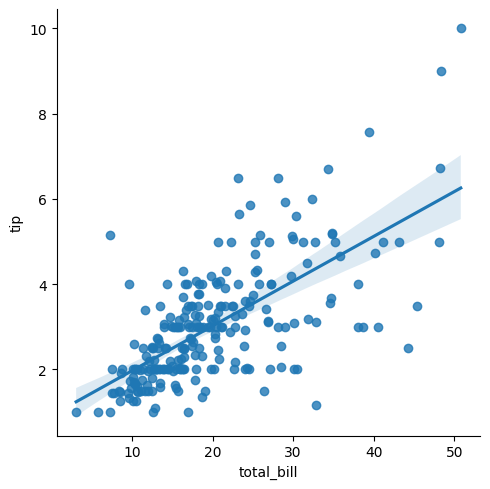

In [3]:
sns.lmplot(x='total_bill', y='tip', data=df)

In [4]:
# scale the data
scalar = StandardScaler()
df[['total_bill', 'tip']] = scalar.fit_transform(df[['total_bill', 'tip']])


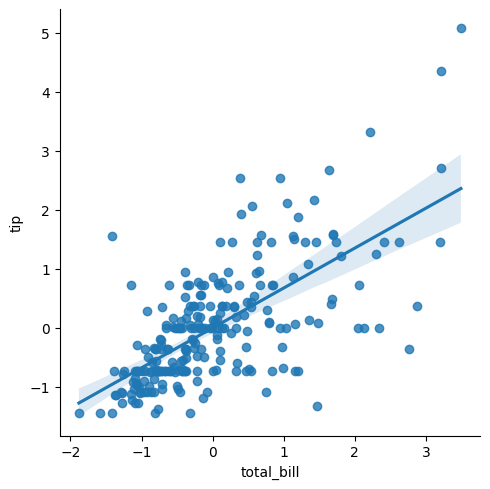

In [5]:
sns.lmplot(x='total_bill', y='tip', data=df)

In [6]:
X = df[['total_bill']]
y = df['tip']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
model.predict([[15]])

c:\Users\iT LOGIX\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10.35454829])

In [11]:
y_pred = model.predict(X_test)

In [12]:
# evaluation of the model
from sklearn.metrics import mean_squared_error, r2_score
print('MSE: ', mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MSE:  0.2983382530785567
R2 : 0.5449381659234667


### Saving and loading trained model

In [13]:
# save the model
import pickle

# creating folder to save the model

import os
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

pickle.dump(model, open('./saved_models/01_linear_regression.pkl', 'wb'))
# wb mean write binary

In [14]:
# loading the model
import pickle
# rb means read binary
model_load = pickle.load(open('./saved_models/01_linear_regression.pkl', 'rb'))

In [15]:
model_load.predict([[15]])

c:\Users\iT LOGIX\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10.35454829])

### Multi LinearRegression

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('tips')
df.head()
X = df[['total_bill', 'size', 'day']]
y = df['tip']

scalar = StandardScaler()
X[['total_bill', 'size']] = scalar.fit_transform(X[['total_bill', 'size']])

le = LabelEncoder()
X['day'] = le.fit_transform(X['day'])
# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

model = LinearRegression()
model.fit(X,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.predict([[105, 3, 1]])

array([90.12601848])

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [19]:
y_pred = model.predict(X_test)

print(f"MSE: ", mean_squared_error(y_pred, y_test))
print(f"R2Score: ", r2_score(y_pred, y_test))
print(f"MAE: : ", mean_absolute_error(y_pred, y_test))



MSE:  0.5959112564437283
R2Score:  0.40598125536433394
MAE: :  0.6374509660747945


### Pipeline

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score


In [25]:
df = sns.load_dataset('tips')
# Seperate the features X and the target/labels y

X = df[['total_bill', 'size', 'day']]
y = df['tip']

# numeric features
numeric_features = ['total_bill', 'size']
# cat features
categorical_features = ['day']

# processor
processor = ColumnTransformer(
    transformers=[
        # the standard scalar will got applied on the columns inside numeric features
        ('num', StandardScaler(), numeric_features),
        # the onehot encoder will apply on the colums in categorical_features
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', processor),
    ('model', LinearRegression())
])

# fit model





In [26]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(f"MSE: ", mean_squared_error(y_pred, y_test))
print(f"R2Score: ", r2_score(y_pred, y_test))
print(f"MAE: : ", mean_absolute_error(y_pred, y_test))

MSE:  0.958419263745229
R2Score:  -0.04646447710382562
MAE: :  0.7308856650334821


In [28]:
pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Big Data

In [14]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression


df = sns.load_dataset('diamonds')

X = df.drop('price', axis=1)
y = df['price']

# numeric features
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
# categorical features
categorical_features = ['cut', 'color', 'clarity']

# perprocess the data

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])


# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)


# create pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


# fit the model
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# evaluation metrics
print(f"MSE: ", mean_squared_error(y_pred, y_test))
print(f"R2Score: ", r2_score(y_pred, y_test))
print(f"MAE: : ", mean_absolute_error(y_pred, y_test))


MSE:  1288705.477851676
R2Score:  0.9128858892590902
MAE: :  737.1513665933282
